# 1 - Network flow based anomaly detector for CICIDS2017
This notebook provides a sample implementation of a flow-based network anomaly detector, which main mission is to tag each network flow with a anomaly index, a number from 0 to 1, indicating the probability that the flow belongs to an attack according to the OD algorithm. This implementation will use [CICIDS2017](https://www.unb.ca/cic/datasets/ids-2017.html) as dataset of reference.

## 1.1 - Preliminary actions

### 1.1.1 - Validate downloaded files

In [1]:
import os
print(os.getcwd())
for root, dirs, files in os.walk('./CSVs'):
        print(root+":")
        if dirs:
            print('\n'.join(dirs))
        if files:
            print('\n'.join(files))
            

/home/users/davide.zhang/Attack Scenario Reconstruction
./CSVs:
.ipynb_checkpoints
merged
results
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Friday-WorkingHours-Morning.pcap_ISCX.csv
Monday-WorkingHours.pcap_ISCX.csv
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Tuesday-WorkingHours.pcap_ISCX.csv
Wednesday-workingHours.pcap_ISCX.csv
./CSVs/.ipynb_checkpoints:
Wednesday-workingHours.pcap_ISCX-checkpoint.csv
./CSVs/merged:
Merged.csv
./CSVs/results:
scenario_reconstruction_dataset.csv


### 1.1.2 - Inspect csv file columns

In [2]:
import csv

files=os.listdir('./CSVs')
for file in files:
    if file.endswith(".csv"):
        print("\n"+file+"\n")
        with open(f"./CSVs/{file}", newline="") as f:
            r=csv.DictReader(f)
            print('\n'.join(name.strip() for name in r.fieldnames))
        


Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv

Flow ID
Source IP
Source Port
Destination IP
Destination Port
Protocol
Timestamp
Flow Duration
Total Fwd Packets
Total Backward Packets
Total Length of Fwd Packets
Total Length of Bwd Packets
Fwd Packet Length Max
Fwd Packet Length Min
Fwd Packet Length Mean
Fwd Packet Length Std
Bwd Packet Length Max
Bwd Packet Length Min
Bwd Packet Length Mean
Bwd Packet Length Std
Flow Bytes/s
Flow Packets/s
Flow IAT Mean
Flow IAT Std
Flow IAT Max
Flow IAT Min
Fwd IAT Total
Fwd IAT Mean
Fwd IAT Std
Fwd IAT Max
Fwd IAT Min
Bwd IAT Total
Bwd IAT Mean
Bwd IAT Std
Bwd IAT Max
Bwd IAT Min
Fwd PSH Flags
Bwd PSH Flags
Fwd URG Flags
Bwd URG Flags
Fwd Header Length
Bwd Header Length
Fwd Packets/s
Bwd Packets/s
Min Packet Length
Max Packet Length
Packet Length Mean
Packet Length Std
Packet Length Variance
FIN Flag Count
SYN Flag Count
RST Flag Count
PSH Flag Count
ACK Flag Count
URG Flag Count
CWE Flag Count
ECE Flag Count
Down/Up Ratio
Average Packet Size
Av

### 1.2.1 - Dataframe merging and label-based test-train splitting for reconstruction

In [3]:
import pandas as pd

df_list=[]
for file in files:
    if file.endswith(".csv") and not file=="Merged.csv":
       df_list.append(pd.read_csv(f"./CSVs/{file}", encoding="latin-1"))
df=pd.concat(df_list)
df.columns = df.columns.str.strip()
df = df.dropna(how='all')
df.info()
print()
print(df['Label'].value_counts())

/tmp/ipykernel_72019/3903524667.py:6: DtypeWarning: Columns (0: Flow ID, 1:  Source IP, 2:  Destination IP, 3:  Timestamp, 4:  Label) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list.append(pd.read_csv(f"./CSVs/{file}", encoding="latin-1"))


<class 'pandas.DataFrame'>
Index: 2830743 entries, 0 to 692702
Data columns (total 85 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Flow ID                      str    
 1   Source IP                    str    
 2   Source Port                  float64
 3   Destination IP               str    
 4   Destination Port             float64
 5   Protocol                     float64
 6   Timestamp                    str    
 7   Flow Duration                float64
 8   Total Fwd Packets            float64
 9   Total Backward Packets       float64
 10  Total Length of Fwd Packets  float64
 11  Total Length of Bwd Packets  float64
 12  Fwd Packet Length Max        float64
 13  Fwd Packet Length Min        float64
 14  Fwd Packet Length Mean       float64
 15  Fwd Packet Length Std        float64
 16  Bwd Packet Length Max        float64
 17  Bwd Packet Length Min        float64
 18  Bwd Packet Length Mean       float64
 19  Bwd Packet Length

In [6]:
import numpy as np
df=df.replace([np.inf, -np.inf, np.nan], -1)

In [ ]:
# compute split index for each group of labels
df["Timestamp"] = pd.to_datetime(df["Timestamp"], dayfirst=True, format='mixed')
df = df.sort_values("Timestamp").reset_index(drop=True)
split_idx_dict={}
for label, group in df.groupby("Label", sort=False):

    group = group.sort_values("Timestamp")

    split_idx = int(len(group) * 0.67)
    split_idx = max(1, min(split_idx, len(group) - 1))
    split_idx_dict[label]=split_idx

    train_parts.append(group.iloc[:split_idx])
    test_parts.append(group.iloc[split_idx:])

train_df = pd.concat(train_parts, ignore_index=True)
test_df = pd.concat(test_parts, ignore_index=True)
print("Train label distribution:")
print(train_df['Label'].value_counts())
print("\nTest label distribution:")
print(test_df['Label'].value_counts())

### 1.2.4 - Saving testset and trainset

In [7]:
train_df.info()
train_df.to_csv("./CSVs/merged/Train.csv",index=False)
test_df.info()
test_df.to_csv("./CSVs/merged/Test.csv",index=False)

<class 'pandas.DataFrame'>
Index: 2830743 entries, 0 to 692702
Data columns (total 85 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Flow ID                      str    
 1   Source IP                    str    
 2   Source Port                  float64
 3   Destination IP               str    
 4   Destination Port             float64
 5   Protocol                     float64
 6   Timestamp                    str    
 7   Flow Duration                float64
 8   Total Fwd Packets            float64
 9   Total Backward Packets       float64
 10  Total Length of Fwd Packets  float64
 11  Total Length of Bwd Packets  float64
 12  Fwd Packet Length Max        float64
 13  Fwd Packet Length Min        float64
 14  Fwd Packet Length Mean       float64
 15  Fwd Packet Length Std        float64
 16  Bwd Packet Length Max        float64
 17  Bwd Packet Length Min        float64
 18  Bwd Packet Length Mean       float64
 19  Bwd Packet Length

## 1.3 - Feature engineering

### 1.3.1 - Load and build the anomaly detection dataset

In [5]:
# replace the attack labels with 1 and the benign label with 0 for anomaly score computation
def replace_
df['Label'] = df['Label'].replace('DoS Hulk', 1) 
df['Label'] = df['Label'].replace('PortScan', 1) 
df['Label'] = df['Label'].replace('DDoS', 1) 
df['Label'] = df['Label'].replace('DoS GoldenEye', 1) 
df['Label'] = df['Label'].replace('FTP-Patator', 1) 
df['Label'] = df['Label'].replace('SSH-Patator', 1) 
df['Label'] = df['Label'].replace('DoS slowloris', 1) 
df['Label'] = df['Label'].replace('DoS Slowhttptest', 1) 
df['Label'] = df['Label'].replace('Bot', 1) 
df['Label'] = df['Label'].replace('Web Attack \x96 Brute Force', 1) 
df['Label'] = df['Label'].replace('Web Attack \x96 XSS', 1) 
df['Label'] = df['Label'].replace('Infiltration', 1) 
df['Label'] = df['Label'].replace('Web Attack \x96 Sql Injection', 1) 
df['Label'] = df['Label'].replace('Heartbleed', 1) 
df['Label'] = df['Label'].replace('BENIGN', 0) 
df['Label'] = pd.to_numeric(df['Label'])
print(df['Label'].value_counts())

Label
0    2273097
1     557646
Name: count, dtype: int64


In [10]:
import numpy as np
import pandas as pd
train_df=pd.read_csv("./CSVs/merged/Train.csv")
test_df=pd.read_csv("./CSVs/merged/Test.csv")
X_train = train_df
X_test = test_df
rec_cols=["Flow ID", "Source IP", "Destination IP", "Timestamp"]
for col in rec_cols:
    X_train = X_train.drop(col, axis=1)
    X_test = X_test.drop(col, axis=1)
y,X=df["Label"], X_train.drop("Label",axis=1)
print(X.columns[np.isinf(X).any(axis=0)])
columns=X.columns
print(columns)
print("contamination: ")
print(y.value_counts().get(1)/len(y))

Index([], dtype='str')
Index(['Source Port', 'Destination Port', 'Protocol', 'Flow Duration',
       'Total Fwd Packets', 'Total Backward Packets',
       'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
       'Fwd Packet Length Max', 'Fwd Packet Length Min',
       'Fwd Packet Length Mean', 'Fwd Packet Length Std',
       'Bwd Packet Length Max', 'Bwd Packet Length Min',
       'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s',
       'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
       'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std',
       'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean',
       'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags',
       'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Lengt

### 1.3.2 - Load and build the scenario reconstruction dataset

In [11]:
import numpy as np
import pandas as pd
X_rec= df.drop("Label",axis=1)
print(X_rec.columns)

Index(['Flow ID', 'Source IP', 'Source Port', 'Destination IP',
       'Destination Port', 'Protocol', 'Timestamp', 'Flow Duration',
       'Total Fwd Packets', 'Total Backward Packets',
       'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
       'Fwd Packet Length Max', 'Fwd Packet Length Min',
       'Fwd Packet Length Mean', 'Fwd Packet Length Std',
       'Bwd Packet Length Max', 'Bwd Packet Length Min',
       'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s',
       'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
       'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std',
       'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean',
       'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags',
       'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
  

In [12]:
from sklearn.model_selection import train_test_split
_, X_rec, _, _ = train_test_split(X_rec, y, test_size=0.3, random_state=42)

### 1.3.4 - Standardization

In [13]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
np_X=scaler.fit_transform(X)
X=pd.DataFrame(np_X, columns=columns)

## 1.4 - Training the classifiers for anomaly detection

### 1.4.1 - Train-test split

In [15]:
import pandas as pd

split_idx = int(len(df) * 0.67)
X_train = X.iloc[:split_idx].copy()
X_test  = X.iloc[split_idx:].copy()
X_rec = X.iloc[split_idx:].copy()
y_train = y.iloc[:split_idx].copy()
y_test  = y.iloc[split_idx:].copy()
X_rec.to_csv("./CSVs/results/reconstruction_dataset_no_labels.csv", index=False)

### 1.4.2 - Train XGBoost

In [55]:
from xgboost import XGBClassifier
xgboost=XGBClassifier(n_estimators=50, random_state=42)
xgboost.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              n_estimators=50, n_jobs=None, num_parallel_tree=None,
              predictor=None, random_state=42, ...)

### 1.4.3 - Train IForest

In [16]:
from pyod.models.iforest import IForest
iforest=IForest(contamination=0.2, n_estimators=500,  n_jobs=10)
iforest.fit(X_train)

,n_estimators,500
,max_samples,'auto'
,contamination,0.2
,max_features,1.0
,bootstrap,False
,n_jobs,10
,behaviour,'old'
,random_state,None
,verbose,0


### 1.4.4 - Train INNE

In [57]:
from pyod.models.inne import INNE
inne=INNE(contamination=0.2, n_estimators=500)
inne.fit(X_train)

INNE(contamination=0.2, max_samples='auto', n_estimators=500,
   random_state=None)

### 1.4.5 - Train LDA

In [58]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
lda=LinearDiscriminantAnalysis(solver='svd')
lda.fit(X_train, y_train)

LinearDiscriminantAnalysis()

### 1.4.6 - Train OCSVM

In [ ]:
from pyod.models.ocsvm import OCSVM
ocsvm=OCSVM(contamination=0.2)
ocsvm.fit(X_train)

## 1.5 - Testing the classifiers for anomaly detection

### 1.5.1 - Test XGBoost 

In [59]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
y_pred=xgboost.predict(X_test)
acc=accuracy_score(y_test, y_pred)
print(f"xgboost test accuracy: {acc:.3f}")
rec=recall_score(y_test, y_pred)
print(f"xgboost test recall: {rec:.3f}")

xgboost test accuracy: 0.999
xgboost test recall: 0.999


### 1.5.2 - Test IForest

In [17]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
y_pred=iforest.predict(X_test)
acc=accuracy_score(y_test, y_pred)
print(f"IForest test accuracy: {acc:.3f}")
rec=recall_score(y_test, y_pred)
print(f"IForest test recall: {rec:.3f}")

/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but IsolationForest was fitted without feature names
  warnings.warn(


IForest test accuracy: 0.666
IForest test recall: 0.280


### 1.5.3 - Test INNE

In [61]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
y_pred=inne.predict(X_test)
acc=accuracy_score(y_test, y_pred)
print(f"INNE test accuracy: {acc:.3f}")
rec=recall_score(y_test, y_pred)
print(f"INNE test recall: {rec:.3f}")

INNE test accuracy: 0.715
INNE test recall: 0.285


### 1.5.4 - Test LDA

In [62]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
y_pred=lda.predict(X_test)
acc=accuracy_score(y_test, y_pred)
print(f"LDA test accuracy: {acc:.3f}")
rec=recall_score(y_test, y_pred)
print(f"LDA test recall: {rec:.3f}")

LDA test accuracy: 0.898
LDA test recall: 0.580


### 1.5.5 - Test OCSVM

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
y_pred=ocsvm.predict(X_test)
acc=accuracy_score(y_test, y_pred)
print(f"LDA test accuracy: {acc:.3f}")
rec=recall_score(y_test, y_pred)
print(f"LDA test recall: {rec:.3f}")

## 1.6 - ROC and Precision-Recall curves

### 1.6.1 - ROC and Precision-Recall curve for XGBoost

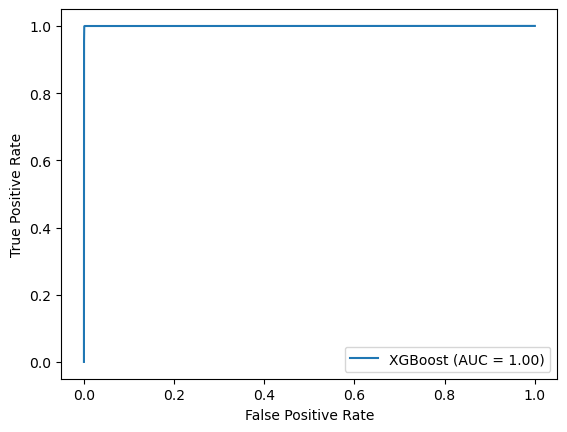

In [63]:
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

y_prob=xgboost.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)
displ = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name="XGBoost")
displ.plot()
plt.show()

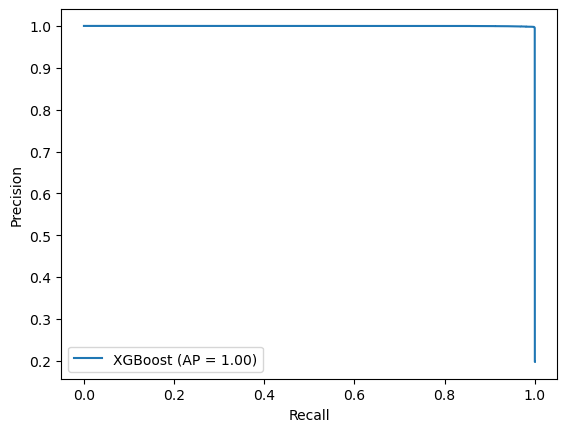

In [64]:
from sklearn.metrics import precision_recall_curve, average_precision_score, PrecisionRecallDisplay
import matplotlib.pyplot as plt

pre, rec, _ = precision_recall_curve(y_test, y_prob)
avg_pre = average_precision_score(y_test, y_prob)
disp=PrecisionRecallDisplay(precision=pre, recall=rec, average_precision=avg_pre, estimator_name="XGBoost")
disp.plot()
plt.show()

### 1.6.2 - ROC and Precision-Recall curve for IForest

/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but IsolationForest was fitted without feature names
  warnings.warn(
/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(


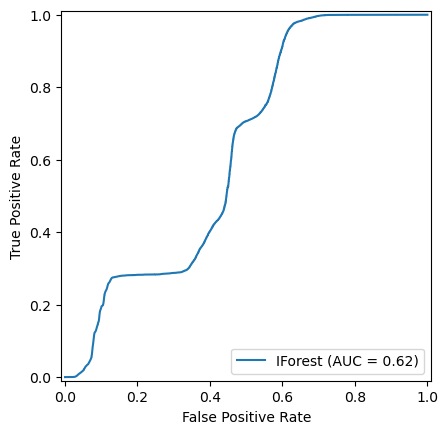

In [18]:
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

y_prob=iforest.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)
displ = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name="IForest")
displ.plot()
plt.show()

/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.8 and will be removed in 1.10. Use `name` instead.
  warnings.warn(


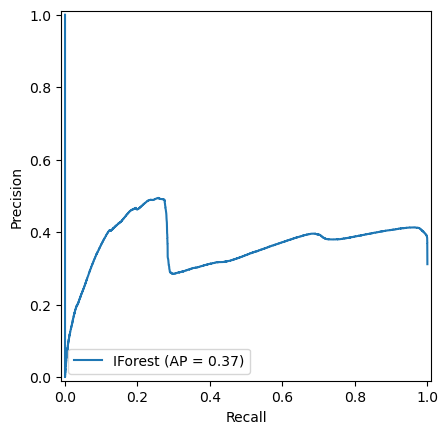

In [19]:
from sklearn.metrics import precision_recall_curve, average_precision_score, PrecisionRecallDisplay
import matplotlib.pyplot as plt

pre, rec, _ = precision_recall_curve(y_test, y_prob)
avg_pre = average_precision_score(y_test, y_prob)
disp=PrecisionRecallDisplay(precision=pre, recall=rec, average_precision=avg_pre, estimator_name="IForest")
disp.plot()
plt.show()

### 1.6.3 - ROC and Precision-Recall curve for INNE

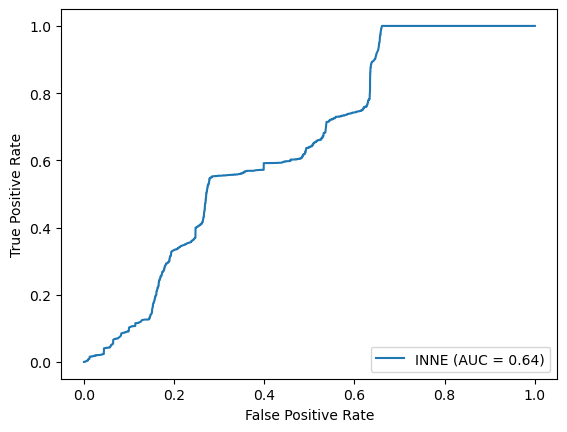

In [67]:
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

y_prob=inne.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)
displ = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name="INNE")
displ.plot()
plt.show()

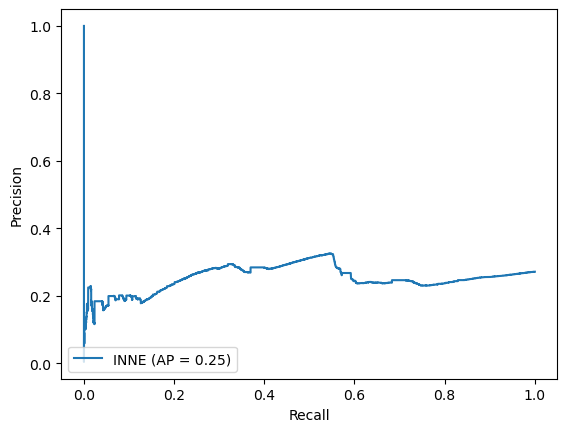

In [68]:
from sklearn.metrics import precision_recall_curve, average_precision_score, PrecisionRecallDisplay
import matplotlib.pyplot as plt

pre, rec, _ = precision_recall_curve(y_test, y_prob)
avg_pre = average_precision_score(y_test, y_prob)
disp=PrecisionRecallDisplay(precision=pre, recall=rec, average_precision=avg_pre, estimator_name="INNE")
disp.plot()
plt.show()

### 1.6.4 - ROC and Precision-Recall curve for LDA

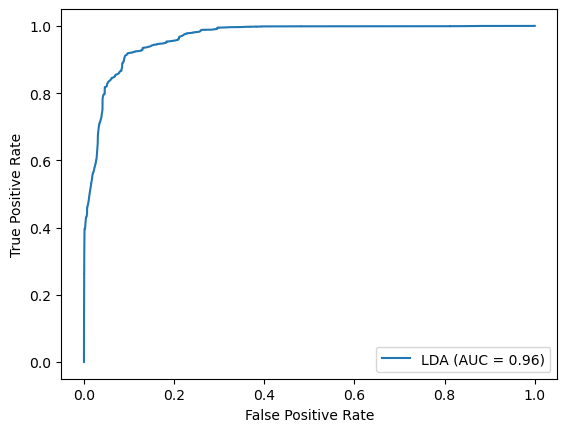

In [69]:
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

y_prob=lda.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)
displ = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name="LDA")
displ.plot()
plt.show()

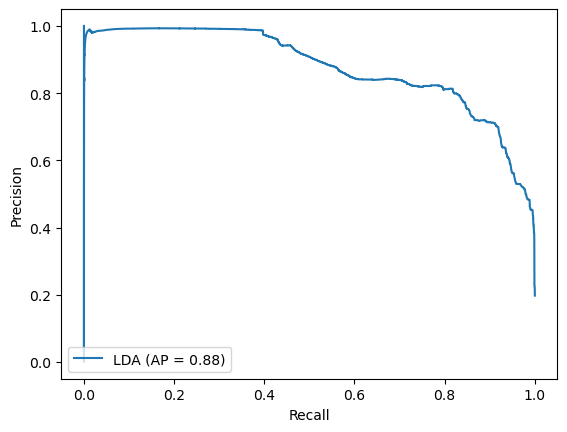

In [70]:
from sklearn.metrics import precision_recall_curve, average_precision_score, PrecisionRecallDisplay
import matplotlib.pyplot as plt

pre, rec, _ = precision_recall_curve(y_test, y_prob)
avg_pre = average_precision_score(y_test, y_prob)
disp=PrecisionRecallDisplay(precision=pre, recall=rec, average_precision=avg_pre, estimator_name="LDA")
disp.plot()
plt.show()

### 1.6.5 - ROC and Precision-Recall curve for OCSVM

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

y_prob=ocsvm.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)
displ = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name="LDA")
displ.plot()
plt.show()

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score, PrecisionRecallDisplay
import matplotlib.pyplot as plt

pre, rec, _ = precision_recall_curve(y_test, y_prob)
avg_pre = average_precision_score(y_test, y_prob)
disp=PrecisionRecallDisplay(precision=pre, recall=rec, average_precision=avg_pre, estimator_name="LDA")
disp.plot()
plt.show()

### 1.6.6 - Save anomaly scores for scenario reconstruction

In [20]:
X_rec['Anomaly score'] = y_prob

## 1.7 - Save the classifier for anomaly detection

In [21]:
import pickle
from sklearn.pipeline import Pipeline
with open("./anomaly_detectors/iforest_a.pkl", "wb") as f_iforest:
    pickle.dump(Pipeline([('scaler', scaler),('iforest', iforest)]), f_iforest)

## 1.8 - Type mapping

### 1.8.1 - Create attack label dictionaries

In [22]:
label_dict={}
for unique_label in unique_labels:
    label_dict[unique_label] = (labels == unique_label).astype(int)

### 1.8.2 - Train-test split

In [23]:
from sklearn.model_selection import train_test_split

all_splits = train_test_split(X, *label_dict.values(), test_size=0.3, random_state=42)
X_train, X_test = all_splits[0], all_splits[1]
y_trains = {}
y_tests = {}
for i, label in enumerate(unique_labels):
    y_trains[label] = all_splits[2 + i*2]
    y_tests[label]  = all_splits[2 + i*2 + 1]

### 1.8.3 - Train XGBoost mappers

In [ ]:
# attack_types_to_be_removed=[]
for attack_type in unique_labels:
    total = len(y_tests[attack_type])
    positives = y_tests[attack_type].sum()
    if positives<1000:
        attack_types_to_be_removed.append(attack_type)
    print(f"{attack_type}: {positives} positives out of {total} ({positives/total*100:.3f}%)")
print('\n'.join(attack_types_to_be_removed))

In [ ]:
from xgboost import XGBClassifier
mapper_dict={}
for attack_type in unique_labels:
    if attack_type not in attack_types_to_be_removed:
        xgboost=XGBClassifier(n_estimators=50, random_state=42)
        xgboost.fit(X_train, y_trains[attack_type])
        mapper_dict[attack_type]=xgboost

### 1.8.4 - Test XGBoost mappers

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
for attack_type, xgboost in mapper_dict.items(): 
    y_pred=xgboost.predict(X_test)
    acc=accuracy_score(y_tests[attack_type], y_pred)
    print(f"xgboost test accuracy for {attack_type}: {acc:.3f}")
    rec=recall_score(y_tests[attack_type], y_pred)
    print(f"xgboost test recall for {attack_type}: {rec:.3f}")

### 1.8.5 - Show ROC and Precision-Recall curve for XGBoost

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay
from sklearn.metrics import precision_recall_curve, average_precision_score, PrecisionRecallDisplay
import matplotlib.pyplot as plt

prob_dict={}

for attack_type, xgboost in mapper_dict.items():
    y_prob = xgboost.predict_proba(X_test)[:, 1]
    prob_dict[attack_type]=y_prob
    
    fpr, tpr, _ = roc_curve(y_tests[attack_type], y_prob)
    roc_auc = roc_auc_score(y_tests[attack_type], y_prob)
    
    fig1, ax1 = plt.subplots()
    RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name="XGBoost "+attack_type).plot(ax=ax1)
    ax1.set_title(f"ROC — {attack_type}")

    pre, rec, _ = precision_recall_curve(y_tests[attack_type], y_prob)
    avg_pre = average_precision_score(y_tests[attack_type], y_prob)
    
    fig2, ax2 = plt.subplots()
    PrecisionRecallDisplay(precision=pre, recall=rec, average_precision=avg_pre, estimator_name="XGBoost "+attack_type).plot(ax=ax2)
    ax2.set_title(f"Precision-Recall — {attack_type}")

plt.show() 

### 1.8.6 - Save attack type score

In [ ]:
for attack_type, y_prob in prob_dict.items():
    X_rec[attack_type]=y_prob

### 1.8.7 - Persist the reconstruction dataset and save the classifiers

In [ ]:
import pandas as pd
X_rec.to_csv("./CSVs/results/scenario_reconstruction_dataset.csv",index=False)

In [ ]:
import pickle
from sklearn.pipeline import Pipeline
with open("Anomaly detectors/mappers_dict.pkl", "wb") as f_mappers:
    pickle.dump(mapper_dict, f_mappers)